## **Machine Learning - Final Group Project**
### **Online News Popularity**


**Group 8:**
- Kéan Lin, 15869962
- Elsa Lin, 15739996
- Lorraine Rui Yan, 15370224

In [ ]:
#This notebook was developed and tested on the following hardware and software:
#CPU: AMD Ryzen 5 7600X
#RAM: 32GB DDR5
#OS: Windows 11 (Home)

#Python: 3.12.7 (Anaconda)
#pandas: 2.2.2
#sckit-learn: 1.6.1
#numpy: 1.26.4
#matplotlib: 3.9.2

#Conda: 24.9.2


In [ ]:
#imports

#core
import pandas as pd
import numpy as np
from scipy import stats


#visualization
import matplotlib.pyplot as plt
from matplotlib import cm #colormap
import seaborn as sns

#sklearn
from sklearn.model_selection import train_test_split, GridSearchCV #for hyperparameter tuning
from sklearn.preprocessing import StandardScaler, MinMaxScaler #for data preprocessing
from sklearn.pipeline import Pipeline #for building ML pipelines
from sklearn.svm import LinearSVC #for SVM classification
from sklearn.linear_model import LogisticRegression #for logistic regression classification
from sklearn.ensemble import RandomForestClassifier #for random forest classification
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier #for boosting algorithms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report #for classification metrics
from sklearn.model_selection import learning_curve #for learning curves
from typing import Optional #for type hinting
from sklearn.cluster import KMeans
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import validation_curve #for validation curves
from sklearn.ensemble import IsolationForest



#fonts
import matplotlib.font_manager as fm
import urllib.request
import os

#color cycle
from cycler import cycler

In [ ]:
#load font

base_url = "https://github.com/googlefonts/dm-fonts/raw/main/Sans/fonts/ttf/"
fonts = {
    "Regular": "DMSans-Regular.ttf",
    "Bold":    "DMSans-Bold.ttf"
}

for weight, filename in fonts.items():
    urllib.request.urlretrieve(base_url + filename, filename)
    #add font
    fm.fontManager.addfont(filename)
    print(f"Added: {filename}")


#colors
PRIMARY   = "#051c2a"  # Deep Navy (primary text)
NAVY      = "#061f79"  # Navy (headings)
BLUE      = "#2251ff"  # Blue (Graphs)
BLUE2     = "#00a9f4"  # Cyan (secondary)
BLUE3     = "#6ecbf7"  # Light Blue (tertiary)
TEAL      = "#99e6ff"  # Teal (fourth level)
ACCENT    = "#051c2a"  # Black (alerts/highlights)
GRAY      = "#757575"  # Neutral Gray (context)
BG        = "#F7FAFC"  # Background (optional)

#apply global settings
plt.rcParams.update({
    #fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["DM Sans", "Arial", "DejaVu Sans"],
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "axes.titleweight": "bold",
    "font.size": 11,

    #colors
    "text.color": PRIMARY,
    "axes.labelcolor": PRIMARY,
    "xtick.color": PRIMARY,
    "ytick.color": PRIMARY,

    #default color cycle
    "axes.prop_cycle": cycler(color=[BLUE, TEAL, ACCENT, GRAY, PRIMARY]),

    #clean layout
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.color": "#E2E8F0",
    "figure.figsize": (10, 6),
})


Added: DMSans-Regular.ttf
Added: DMSans-Bold.ttf


In [ ]:
#load dataset
url = 'https://raw.githubusercontent.com/kean-l/ml_final_project_files/af7e369dd2d2f8f571c546dbca9991c61902a585/OnlineNewsPopularity.csv'
df = pd.read_csv(url, sep=',')

#we strip the columns that have a space in front to make it more convenient to work with
df.columns = df.columns.str.strip()

In [ ]:
pd.options.display.max_columns = None
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,496.0,496.0,496.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500331,0.378279,0.040005,0.041263,0.040123,0.521617,0.092562,0.045662,0.013699,0.769231,0.230769,0.378636,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.799756,0.050047,0.050096,0.050101,0.050001,0.341246,0.148948,0.043137,0.015686,0.733333,0.266667,0.286915,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,918.0,918.0,918.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217792,0.033334,0.033351,0.033334,0.682188,0.702222,0.323333,0.056872,0.009479,0.857143,0.142857,0.495833,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028573,0.419300,0.494651,0.028905,0.028572,0.429850,0.100705,0.041431,0.020716,0.666667,0.333333,0.385965,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,545.0,16000.0,3151.157895,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028633,0.028794,0.028575,0.028572,0.885427,0.513502,0.281003,0.074627,0.012127,0.860215,0.139785,0.411127,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [ ]:
df.describe()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,4.548239,7.223767,0.052946,0.178009,0.157855,0.058597,0.185299,0.212567,26.106801,1153.951682,312.366967,13612.354102,752324.066694,259281.938083,1117.146610,5657.211151,3135.858639,3998.755396,10329.212662,6401.697580,0.168020,0.186409,0.187544,0.183306,0.143805,0.061876,0.069039,0.130915,0.184599,0.141256,0.216321,0.223770,0.234029,0.443370,0.119309,0.039625,0.016612,0.682150,0.287934,0.353825,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,0.844406,1.909130,0.223929,0.382525,0.364610,0.234871,0.388545,0.409129,69.633215,3857.990877,620.783887,57986.029357,214502.129573,135102.247285,1137.456951,6098.871957,1318.150397,19738.670516,41027.576613,24211.332231,0.373889,0.389441,0.390353,0.386922,0.350896,0.240933,0.253524,0.337312,0.262975,0.219707,0.282145,0.295191,0.289183,0.116685,0.096931,0.017429,0.010828,0.190206,0.156156,0.104542,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.393750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,4.478404,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,445.000000,141.750000,0.000000,843300.000000,172846.875000,0.000000,3562.101631,2382.448566,639.000000,1100.000000,981.187500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.025051,0.025012,0.028571,0.028571,0.0

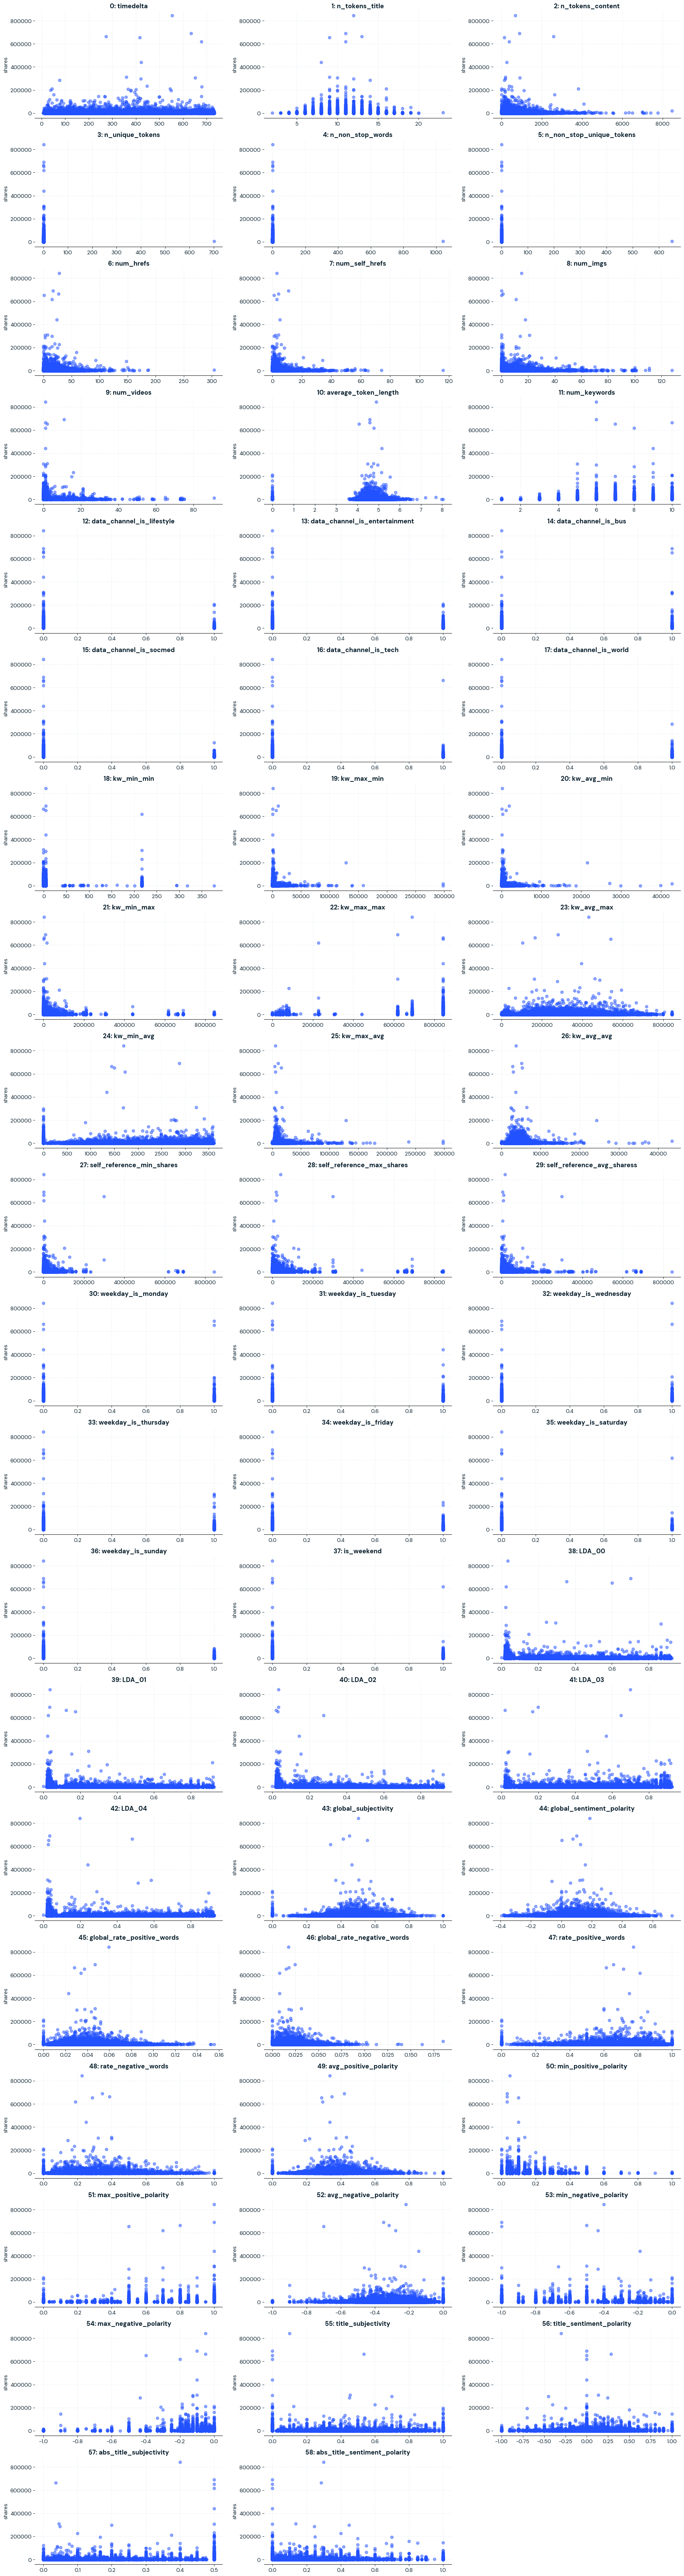

In [ ]:
def scatter_plots(df1, df2):
    feature_names = df1.columns
    fig, axes = plt.subplots(20,3, figsize=(20,75))
    for i, ax in enumerate(axes.ravel()):
        if i > 58:
            ax.set_visible(False)
            continue
        ax.plot(df1.iloc[:, i], df2, 'o', alpha=.5)
        ax.set_title("{}: {}".format(i, feature_names[i]))
        ax.set_ylabel("shares")
    plt.tight_layout()
    plt.show()

scatter_plots(df.drop(columns=['url','shares']), df[['shares']])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            39644 non-null  object 
 1   timedelta                      39644 non-null  float64
 2   n_tokens_title                 39644 non-null  float64
 3   n_tokens_content               39644 non-null  float64
 4   n_unique_tokens                39644 non-null  float64
 5   n_non_stop_words               39644 non-null  float64
 6   n_non_stop_unique_tokens       39644 non-null  float64
 7   num_hrefs                      39644 non-null  float64
 8   num_self_hrefs                 39644 non-null  float64
 9   num_imgs                       39644 non-null  float64
 10  num_videos                     39644 non-null  float64
 11  average_token_length           39644 non-null  float64
 12  num_keywords                   39644 non-null 

<Axes: xlabel='shares', ylabel='Count'>

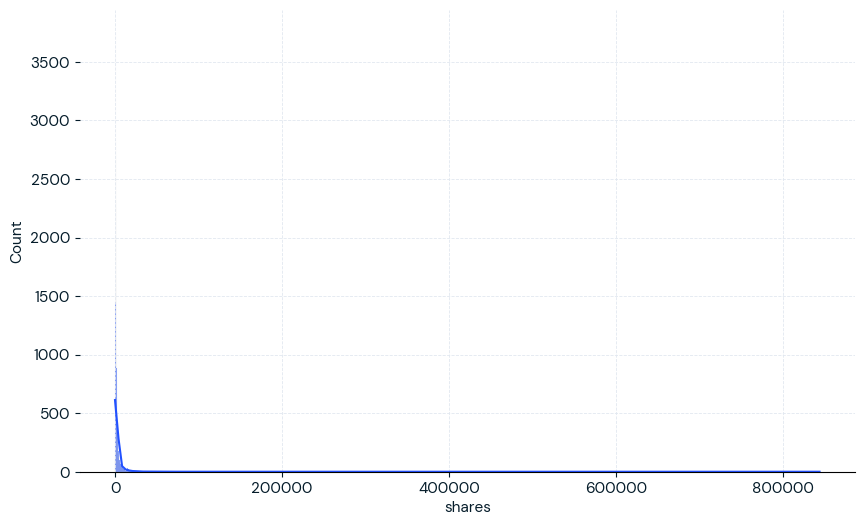

In [ ]:
sns.histplot(df['shares'], kde=True)

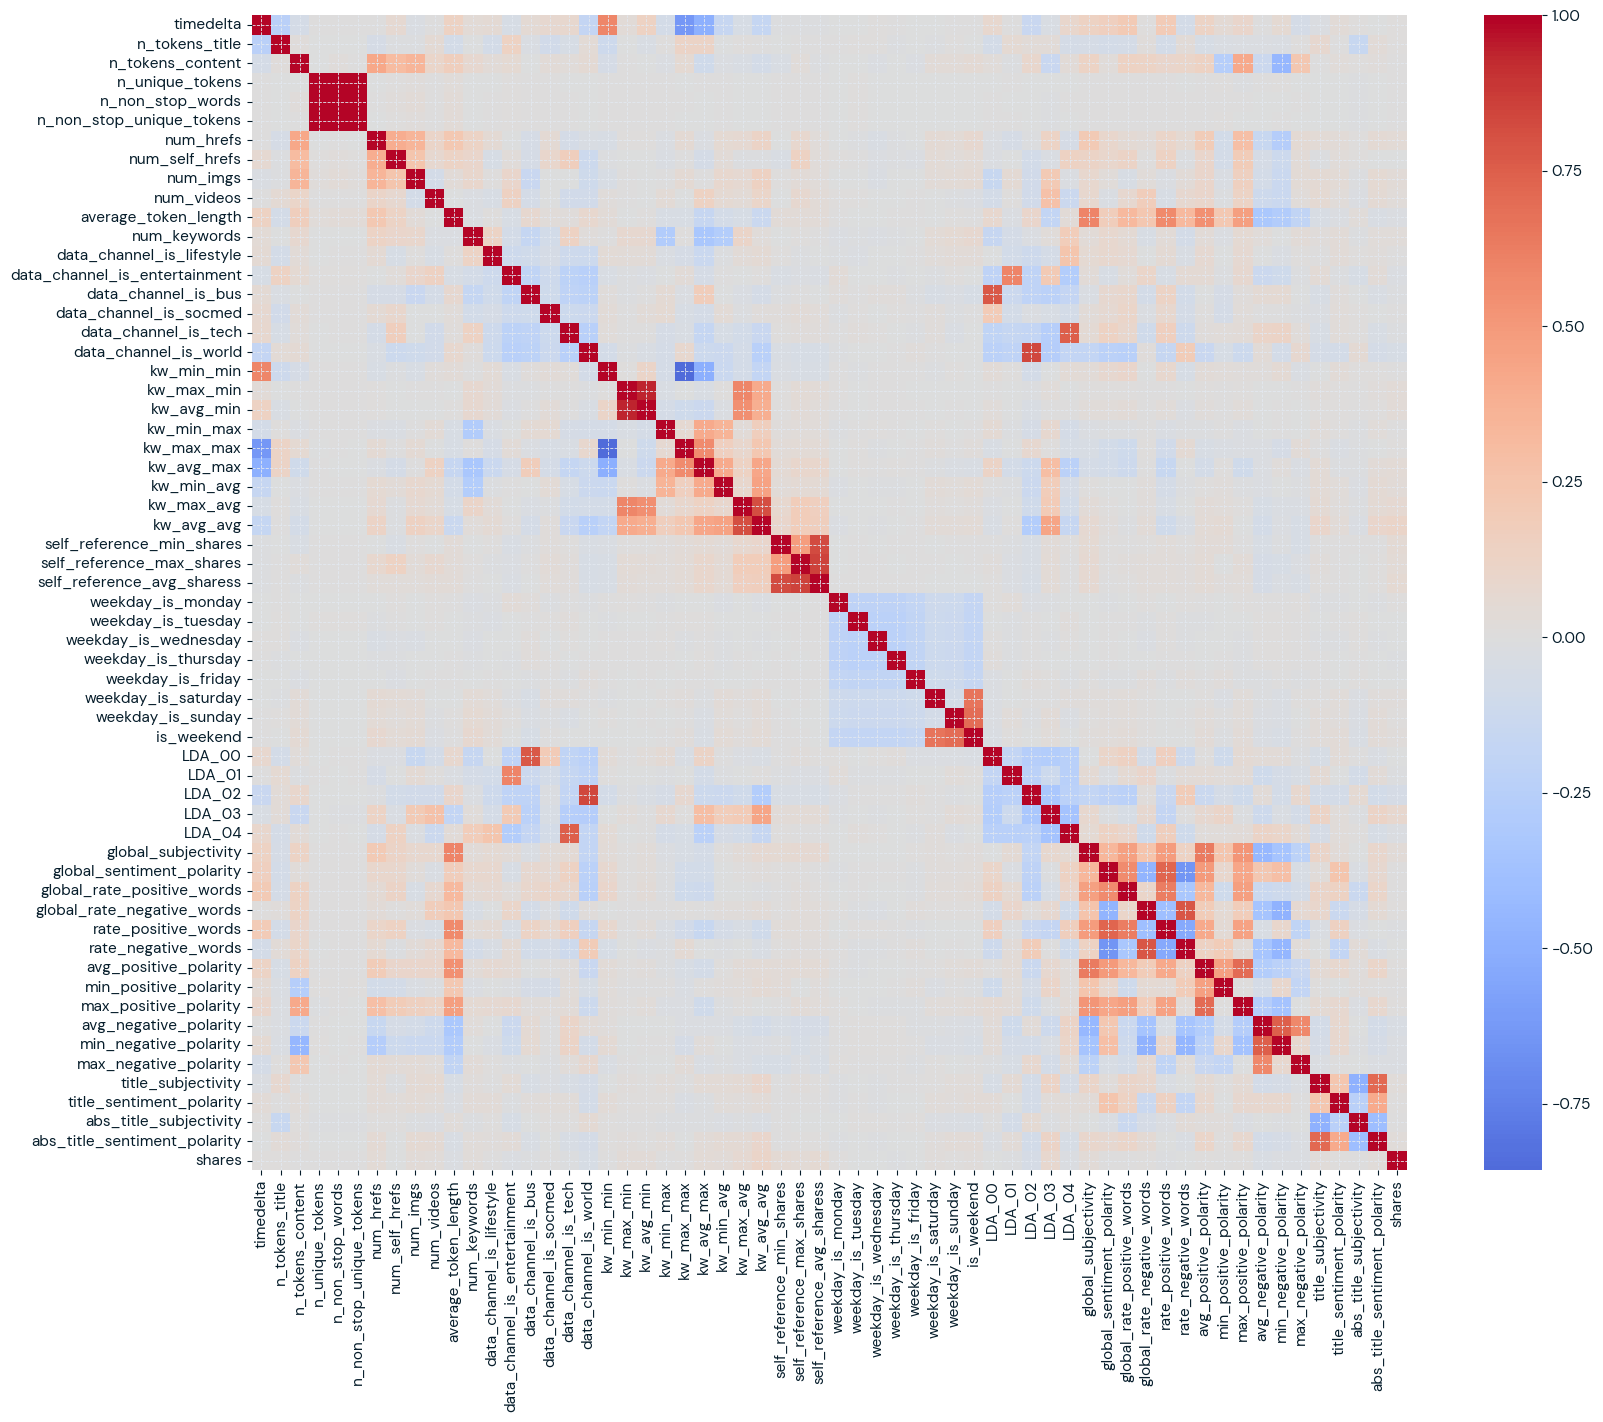

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(
    df.drop(columns=['url']).corr(),
    cmap='coolwarm',
    center=0,
    square=True,
)

plt.show()

In [ ]:
#drop non-predictive columns from the start because will not need them
df = df.drop(columns=['url', 'timedelta'])

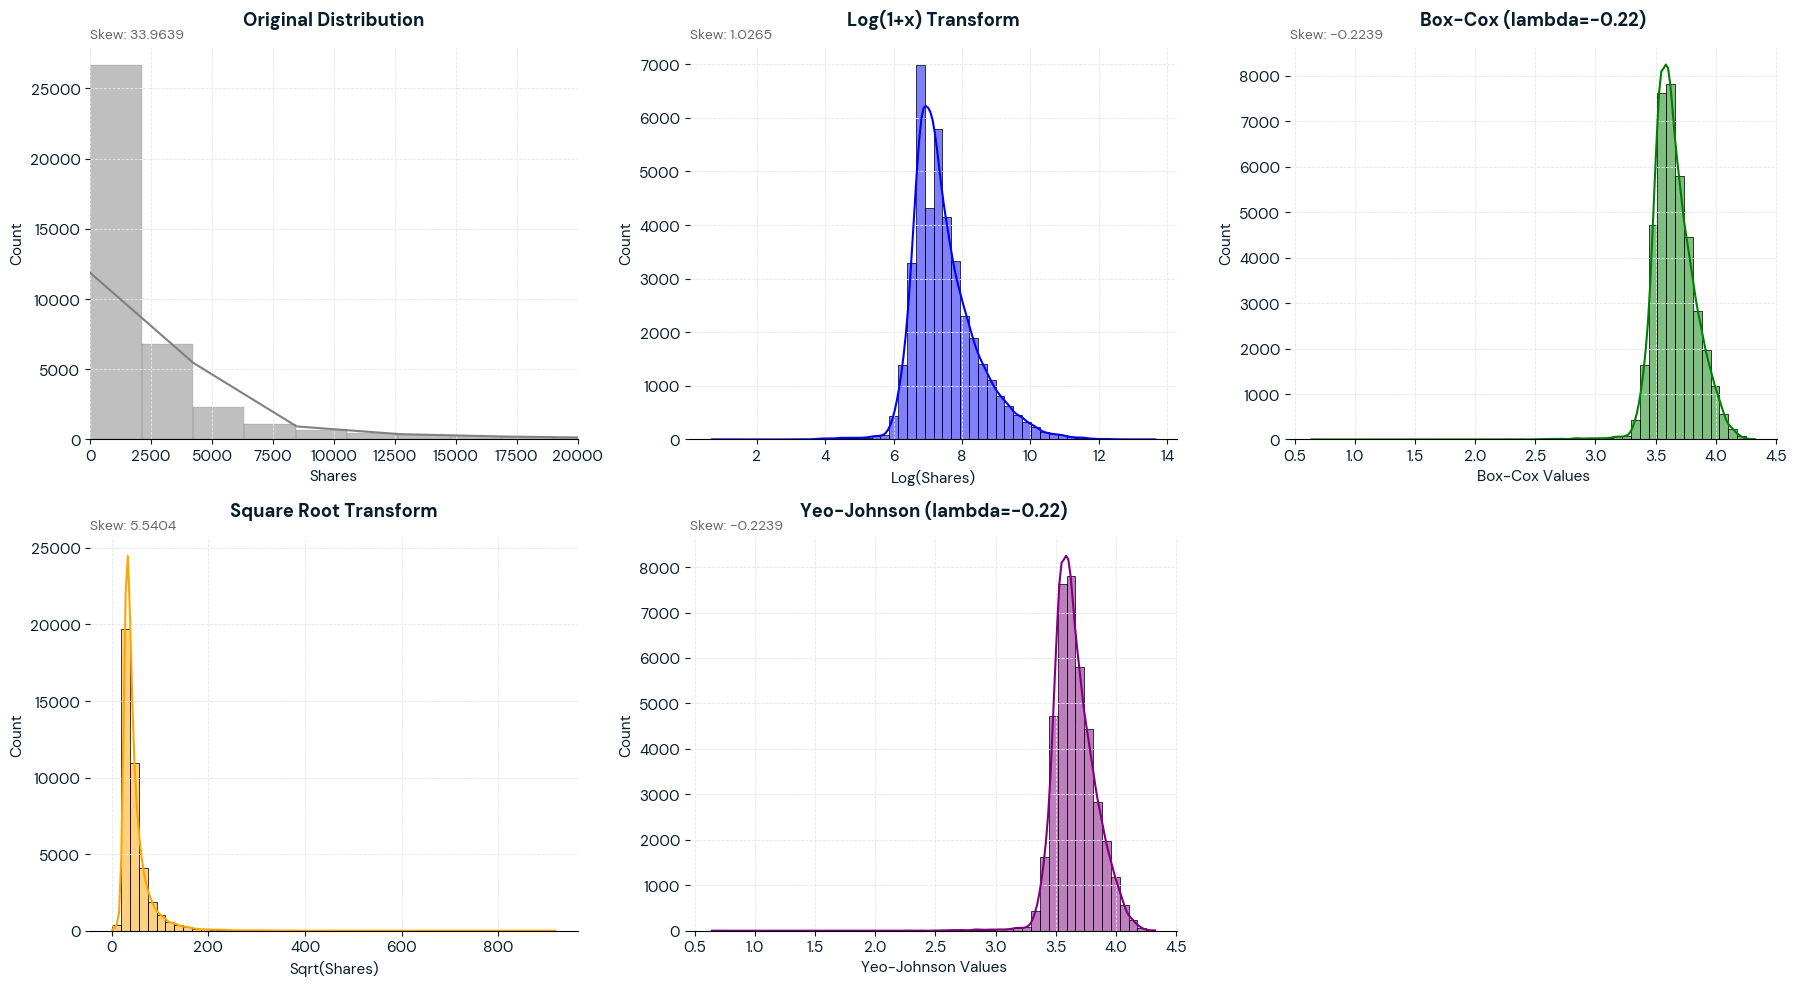

Optimal Box-Cox lambda: -0.2196
Optimal Yeo-Johnson lambda: -0.2196
Skewness values:
Original: 33.9639
Log(1+x): 1.0265
Sqrt: 5.5404
Box-Cox (lambda=-0.22): -0.2239
Yeo-Johnson (lambda=-0.22): -0.2239


In [ ]:
#######################################################################################################
#Skewness correction comparison between Log, sqrt, Box-Cox, Yeo-Johnson vs original
#######################################################################################################


og_shares = df['shares']
log_shares = np.log1p(df['shares'])
sqrt_shares = np.sqrt(df['shares'])
boxcox_shares, best_lambda_box = stats.boxcox(df['shares'] + 1)
yeojohnson_shares, best_lambda_yj = stats.yeojohnson(df['shares'])

#skewness
skew_orig = og_shares.skew()
skew_log = pd.Series(log_shares).skew()
skew_sqrt = pd.Series(sqrt_shares).skew()
skew_box = pd.Series(boxcox_shares).skew()
skew_yj = pd.Series(yeojohnson_shares).skew()



#plotting (we use sns for kde)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

#1: og
sns.histplot(og_shares, bins=400, kde=True, ax=axes[0], color='gray')
axes[0].set_title("Original Distribution", pad=15)
axes[0].text(0, 1.02, f'Skew: {skew_orig:.4f}',
             transform=axes[0].transAxes,
             fontsize=10,
             fontweight='normal',
             color='#666666')
axes[0].set_xlabel('Shares')
axes[0].set_xlim(0, 20000) #zoom

#2: log
sns.histplot(log_shares, bins=50, kde=True, ax=axes[1], color='blue')
axes[1].set_title("Log(1+x) Transform", pad=15)
axes[1].text(0, 1.02, f'Skew: {skew_log:.4f}',
             transform=axes[1].transAxes,
             fontsize=10,
             fontweight='normal',
             color='#666666')
axes[1].set_xlabel('Log(Shares)')

#3: box-cox
sns.histplot(boxcox_shares, bins=50, kde=True, ax=axes[2], color='green')
axes[2].set_title(f'Box-Cox (lambda={best_lambda_box:.2f})', pad=15)
axes[2].text(0, 1.02, f'Skew: {skew_box:.4f}',
             transform=axes[2].transAxes,
             fontsize=10,
             fontweight='normal',
             color='#666666')
axes[2].set_xlabel('Box-Cox Values')

#4: sqrt
sns.histplot(sqrt_shares, bins=50, kde=True, ax=axes[3], color='orange')
axes[3].set_title("Square Root Transform", pad=15)
axes[3].text(0, 1.02, f'Skew: {skew_sqrt:.4f}',
             transform=axes[3].transAxes,
             fontsize=10,
             fontweight='normal',
             color='#666666')
axes[3].set_xlabel('Sqrt(Shares)')

#5: yeo-johnson
sns.histplot(yeojohnson_shares, bins=50, kde=True, ax=axes[4], color='purple')
axes[4].set_title(f'Yeo-Johnson (lambda={best_lambda_yj:.2f})', pad=15)
axes[4].text(0, 1.02, f'Skew: {skew_yj:.4f}',
             transform=axes[4].transAxes,
             fontsize=10,
             fontweight='normal',
             color='#666666')
axes[4].set_xlabel('Yeo-Johnson Values')

#remove empty 6th plot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

#print optimal lambdas
print(f"Optimal Box-Cox lambda: {best_lambda_box:.4f}")
print(f"Optimal Yeo-Johnson lambda: {best_lambda_yj:.4f}")

#print winner
print("Skewness values:")
print(f"Original: {skew_orig:.4f}")
print(f"Log(1+x): {skew_log:.4f}")
print(f"Sqrt: {skew_sqrt:.4f}")
print(f"Box-Cox (lambda={best_lambda_box:.2f}): {skew_box:.4f}")
print(f"Yeo-Johnson (lambda={best_lambda_yj:.2f}): {skew_yj:.4f}")


We observe that Box-Cox achieves a skewness closest to 0 (as well as Yeo-Johnson). However, since 'viral' articles are outliers by nature, Box-Cox has normalized the distribution too much, which makes it hard to measure the 'virality'. Therefore we will choose the Log(1+x) transformation, which reduces skewness effectively, while preserving the heavy tail necessary for detecting viral content.

K-Means popularity threshold is: 2600 shares
Number of 'viral' articles: 10866 (27.4%)


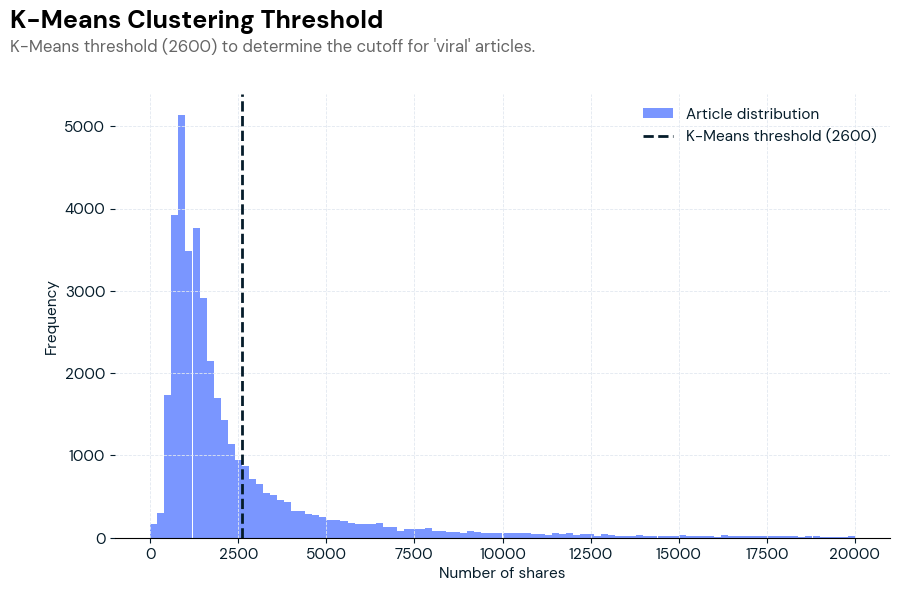

In [ ]:
#######################################################################################################
#K-Means Clustering
#######################################################################################################


# We use log because shares are highly skewed (long tail)
shares_log = np.log1p(df['shares']).values.reshape(-1, 1)


#2 clusters, "Ordinary" vs "Viral"
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(shares_log)

#determine threshold
cluster_centers = kmeans.cluster_centers_
high_cluster_id = np.argmax(cluster_centers)

#filter the original shares that belong to the high cluster
high_shares = df['shares'].iloc[np.where(clusters == high_cluster_id)]
threshold = high_shares.min()

print(f"K-Means popularity threshold is: {threshold} shares")
print(f"Number of 'viral' articles: {len(high_shares)} ({len(high_shares)/len(df)*100:.1f}%)")

#plotting
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['shares'], bins=100, range=(0, 20000), color=BLUE, alpha=0.6, label='Article distribution')
ax.axvline(threshold, color=ACCENT, linestyle='--', linewidth=2, label=f'K-Means threshold ({threshold})')
ax.set_xlabel('Number of shares')
ax.set_ylabel('Frequency')
ax.legend(frameon=False, loc='upper right')
fig.text(0.02, 0.96, "K-Means Clustering Threshold",
         fontsize=18, fontweight='bold', ha='left', color='black')
fig.text(0.02, 0.92, f"K-Means threshold ({threshold}) to determine the cutoff for 'viral' articles.",
         fontsize=12, ha='left', color='#666666')
plt.subplots_adjust(top=0.85)

plt.show()


We observe that K-Means clustering determined the natural popularity threshold at 2600 shares (72.6/27.4 split).

From a business perspective, a standard approach to defining popularity is the Pareto Principle (80/20 rule). However, when applying this rule the threshold would be set at 3400 shares. This is too restrictive for our goals, since it could overlook certain 'high-performing' articles and introduce a severe class imbalance.

Therefore, we will choose a 2800 shares threshold. This balances both business standards and our data insight. This 75/25 split ensures a metric that is statistically robust while inclusive enough to avoid severe class imbalance.


In [ ]:
############################################################################################################
# DATA PREPARATION FOR SUPERVISED LEARNING
############################################################################################################

#create binary target var is_popular: 1 if shares >= 2800 (based on research above, 75/25 split), else 0
df['is_popular'] = (df['shares'] >= 2800).astype(int)

#we observe that the url and timedelta (potential leakage) columns are non-predictive
#drop columns that are non-predictive (already done in earlier step) + shares (target var)
df_clean = df.drop(columns=['shares'])

#split data into X and y
X = df_clean.drop(columns=['is_popular'])
y = df_clean['is_popular']

#80 20 split + stratify to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 31715
Testing samples: 7929


In [ ]:
############################################################################################################
# SETUP
############################################################################################################

#comparing these two scalers to see which one achieves higher accuracy
scalers = [StandardScaler, MinMaxScaler]

#list of models (has been tuned already)
#models = [
#    (LogisticRegression, 'estimator__C', np.logspace(-4, 4, 10)),
#    (RandomForestClassifier, 'estimator__max_depth', [2, 4, 8, 15, 16, 17, 32]), #added 15, 17 for finetuning
#    (AdaBoostClassifier, 'estimator__n_estimators', [50, 100, 200]),
#    (HistGradientBoostingClassifier, 'estimator__max_iter', [100, 300, 500]) #optimized range for the lower learning rate
#]

#list of models (raw)
models = [
    (LogisticRegression, 'estimator__C', np.logspace(-4, 4, 10)),
    (RandomForestClassifier, 'estimator__max_depth', [2, 4, 8, 16, 32]),
    (AdaBoostClassifier, 'estimator__n_estimators', [50, 100, 200]),
    (HistGradientBoostingClassifier, 'estimator__max_iter', [50, 100, 200])
]

In [ ]:
def compute_classification_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0.),
        'precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0.),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0.),
        'recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0.),
        'f1_score': f1_score(y_true, y_pred),
    }

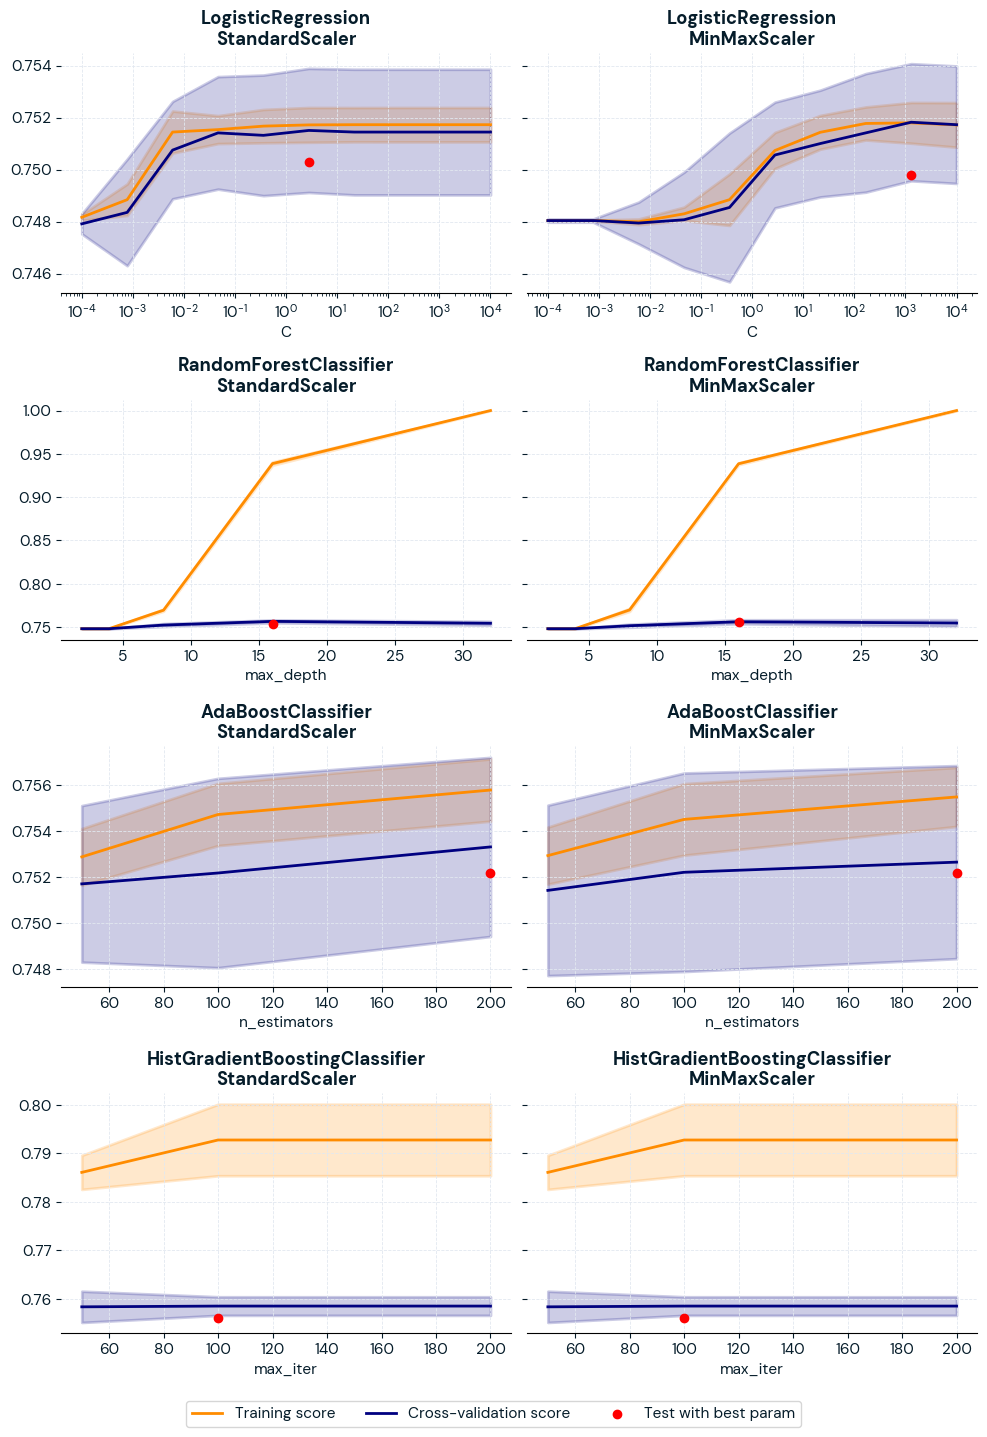

In [ ]:
############################################################################################################
# CALCULATING & VISUALIZATION
############################################################################################################

ncols, nrows = len(scalers), len(models)
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5 * ncols, 3.5 * nrows), tight_layout=True, sharey='row')
axs = axs.ravel()

results = {}

for row, (estimator_cls, param_name, param_range) in enumerate(models):
    for col, scaler_cls in enumerate(scalers):

        ax = axs[row * ncols + col]

        #initialize models
        if estimator_cls == LogisticRegression:
            model = estimator_cls(max_iter=2000, random_state=42, n_jobs=-1)
        elif estimator_cls == RandomForestClassifier:
            model = estimator_cls(n_estimators=100, random_state=42, n_jobs=-1)
        elif estimator_cls == AdaBoostClassifier:
            model = estimator_cls(random_state=42)
        elif estimator_cls == HistGradientBoostingClassifier:
            #optimize hyperparameters later: learning_rate=0.05, l2_regularization=1.0
            model = estimator_cls(random_state=42)

        #pipeline
        pipe = Pipeline([
            ('scaler', scaler_cls()),
            ('estimator', model),
        ])

        # return_train_score=True to plot w/o retraining
        #grid search w/ CV=5
        grid = GridSearchCV(pipe, {param_name: param_range}, return_train_score=True, cv=5, scoring='accuracy', n_jobs=-1)

        #train on full training set
        grid.fit(X_train, y_train)

        best_estimator = grid.best_estimator_
        best_param_value = grid.best_params_[param_name]

        #calculate test score
        y_test_score = grid.scorer_(best_estimator, X_test, y_test)

        #extract cv results to plot
        res = grid.cv_results_
        train_mean = res['mean_train_score']
        train_std = res['std_train_score']
        test_mean = res['mean_test_score']
        test_std = res['std_test_score']

        # plot training curve (orange)
        ax.plot(param_range, train_mean, label="Training score", color="darkorange", lw=2)
        ax.fill_between(param_range, train_mean - train_std, train_mean + train_std,
                        alpha=0.2, color="darkorange", lw=2)

        # plot validation curve (navy)
        ax.plot(param_range, test_mean, label="Cross-validation score", color="navy", lw=2)
        ax.fill_between(param_range, test_mean - test_std, test_mean + test_std,
                        alpha=0.2, color="navy", lw=2)

        # plot test point (red)
        ax.scatter(best_param_value, y_test_score, color='red', label='Test with best param', zorder=5)

        metrics = compute_classification_metrics(y_test, best_estimator.predict(X_test))
        results[(estimator_cls.__name__, scaler_cls.__name__)] = metrics

        # formatting
        ax.set_title(f'{estimator_cls.__name__}\n{scaler_cls.__name__}')
        ax.set_xlabel(param_name.split('__')[1])

        # set log scale for C parameter (LogReg)
        if 'C' in param_name:
            ax.set_xscale('log')

        if col != 0: ax.set_ylabel('')

#single legend for the whole figure
handles, labels = axs[0].get_legend_handles_labels()
labels = ['Validation' if label == 'Test' else label for label in labels]
unique_labels = dict(zip(labels, handles))
fig.legend(unique_labels.values(), unique_labels.keys(), bbox_to_anchor=(0.5, 0.), loc='upper center', ncol=3)

plt.show()



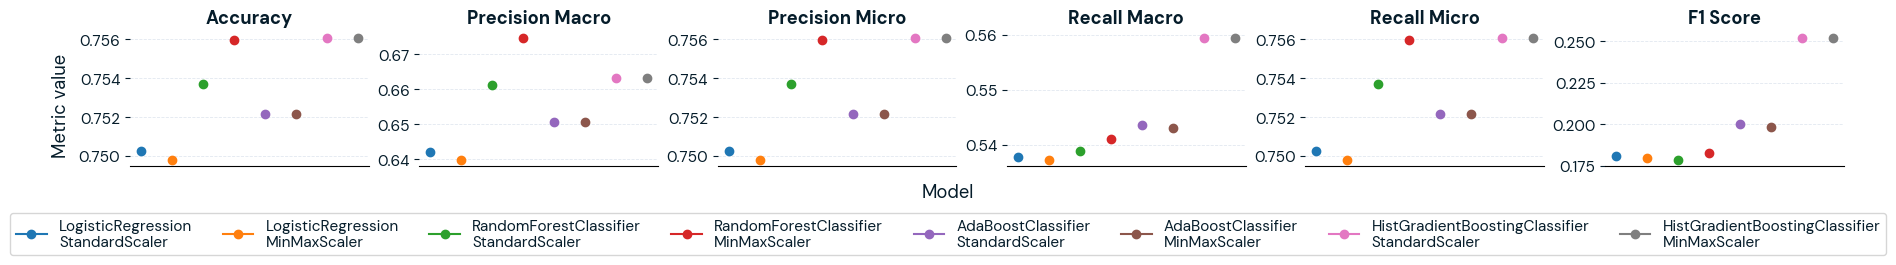

accuracy  precision_macro  \
LogisticRegression             StandardScaler  0.750284         0.642256   
                               MinMaxScaler    0.749779         0.639742   
RandomForestClassifier         StandardScaler  0.753689         0.661405   
                               MinMaxScaler    0.755959         0.674826   
AdaBoostClassifier             StandardScaler  0.752176         0.650705   
                               MinMaxScaler    0.752176         0.650836   
HistGradientBoostingClassifier StandardScaler  0.756085         0.663330   
                               MinMaxScaler    0.756085         0.663330   

                                               precision_micro  recall_macro  \
LogisticRegression             StandardScaler         0.750284      0.537860   
                               MinMaxScaler           0.749779      0.537191   
RandomForestClassifier         StandardScaler         0.753689      0.538974   
                               MinMaxScaler           0.755959      0.541156   
AdaBoostClassifier             StandardScaler         0.752176      0.543605   
                               MinMaxScaler           0.752176      0.543107   
HistGradientBoostingClassifier StandardScaler         0.756085      0.559494   
                               MinMaxScaler           0.756085      0.559494   

                                               recall_micro  f1_score  
LogisticRegression             StandardScaler      0.750284  0.181141  
                               MinMaxScaler        0.749779  0.179487  
RandomForestClassifier         StandardScaler      0.753689  0.178376  
                               MinMaxScaler        0.755959  0.182510  
AdaBoostClassifier             StandardScaler      0.752176  0.200244  
                               MinMaxScaler        0.752176  0.198286  
HistGradientBoostingClassifier StandardScaler      0.756085  0.252127  
                               MinMaxScaler        0.756085  0.252127

In [ ]:
#derived from assignment_3_solutions file
def plot_results(df: pd.DataFrame, cmap = plt.get_cmap('tab10'), ncol: Optional[int] = None):
    # Create model labels combining both index levels
    df = df.copy()
    df['model'] = [f'{model}\n{scaler}' for model, scaler in df.index]
    metrics = [col for col in df.columns if col != 'model']

    # Create subplots
    n_metrics = len(metrics)
    fig, axs = plt.subplots(1, n_metrics, figsize=(3 * n_metrics, 2), constrained_layout=True)
    axs = axs.flatten()

    colors = [cmap(i) for i in range(len(df))]


    for ax, metric in zip(axs, metrics, strict=True):
        # Plot horizontal lines with markers for each model
        for i, (_, row) in enumerate(df.iterrows()):
            ax.plot(i, row[metric], 'o-', color=colors[i], label=row['model'])

        ax.set_title(metric.replace('_', ' ').title())
        ax.set_xticks([])

    # Add a single legend for all subplots
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.), ncol=len(labels) if ncol is None else ncol)
    fig.supxlabel('Model')
    fig.supylabel('Metric value')

    plt.show()

df_results = pd.DataFrame(results).T
plot_results(df_results)
df_results

Raw Supervised models:

We observe that all models show ~75% accuracy: because that is the 'null accuracy' baseline since 75% of this dataset are non-popular articles, a naive model that predicts 'non popular' for every instance would also achieve this score.

We will tweak the hyperparameters in order to optimize the models. We will optimize for F1 score instead of Accuracy to force the model to value the minority class, add regularization, and balance classes.

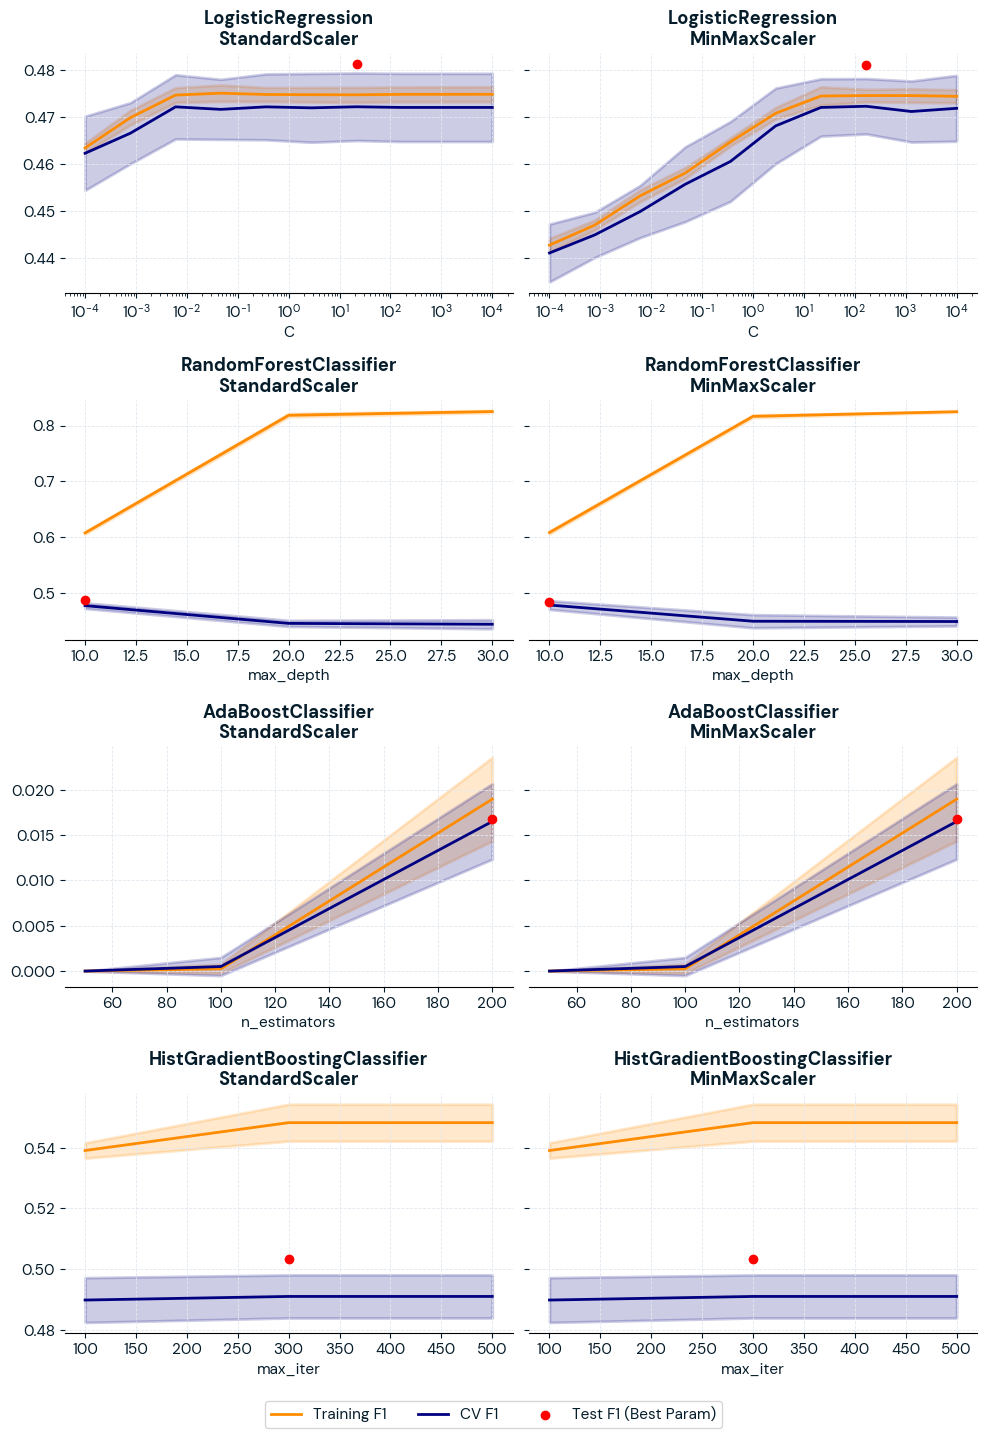

In [ ]:
############################################################################################################
# CALCULATING & VISUALIZATION (PART 2: OPTIMIZED w/ regularization)
############################################################################################################

# new ranges after hyperparameter tuning
models = [
    (LogisticRegression, 'estimator__C', np.logspace(-4, 4, 10)),
    (RandomForestClassifier, 'estimator__max_depth', [10, 20, 30]),
    (AdaBoostClassifier, 'estimator__n_estimators', [50, 100, 200]),
    (HistGradientBoostingClassifier, 'estimator__max_iter', [100, 300, 500])
]

ncols, nrows = len(scalers), len(models)
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5 * ncols, 3.5 * nrows), tight_layout=True, sharey='row')
axs = axs.ravel()

results = {}

for row, (estimator_cls, param_name, param_range) in enumerate(models):
    for col, scaler_cls in enumerate(scalers):

        ax = axs[row * ncols + col]

        # initialize models with regularization and optimized hyperparameters
        if estimator_cls == LogisticRegression:
            model = estimator_cls(
                max_iter=2000,
                random_state=42,
                n_jobs=-1,
                class_weight='balanced' # added balance
            )

        elif estimator_cls == RandomForestClassifier:
            model = estimator_cls(
                n_estimators=100,
                max_features='sqrt',
                min_samples_leaf=10,     # increased for regularization
                random_state=42,
                n_jobs=-1,
                class_weight='balanced'  # added balance
            )

        elif estimator_cls == AdaBoostClassifier:
            model = estimator_cls(
                learning_rate=0.1,
                random_state=42
            )

        elif estimator_cls == HistGradientBoostingClassifier:
            model = estimator_cls(
                learning_rate=0.05,
                l2_regularization=1.0,
                max_leaf_nodes=20,
                min_samples_leaf=20,
                random_state=42,
                class_weight='balanced' # added balance
            )

        #pipeline
        pipe = Pipeline([
            ('scaler', scaler_cls()),
            ('estimator', model),
        ])

        # grid search
        #changed scoring to f1 to handle class imbalance
        grid = GridSearchCV(pipe, {param_name: param_range}, return_train_score=True, cv=5, scoring='f1', n_jobs=-1)

        # train on full training set
        grid.fit(X_train, y_train)

        best_estimator = grid.best_estimator_
        best_param_value = grid.best_params_[param_name]

        # calculate test score
        # changed scoring to f1 to handle class imbalance
        y_test_score = grid.scorer_(best_estimator, X_test, y_test)

        # extract cv results
        res = grid.cv_results_
        train_mean = res['mean_train_score']
        train_std = res['std_train_score']
        test_mean = res['mean_test_score']
        test_std = res['std_test_score']

        # plot training curve
        ax.plot(param_range, train_mean, label="Training F1", color="darkorange", lw=2)
        ax.fill_between(param_range, train_mean - train_std, train_mean + train_std,
                        alpha=0.2, color="darkorange", lw=2)

        # plot validation curve
        ax.plot(param_range, test_mean, label="CV F1", color="navy", lw=2)
        ax.fill_between(param_range, test_mean - test_std, test_mean + test_std,
                        alpha=0.2, color="navy", lw=2)

        # plot test point
        ax.scatter(best_param_value, y_test_score, color='red', label='Test F1 (Best Param)', zorder=5)

        #metrics
        metrics = compute_classification_metrics(y_test, best_estimator.predict(X_test))
        results[(estimator_cls.__name__, scaler_cls.__name__)] = metrics

        # formatting
        ax.set_title(f'{estimator_cls.__name__}\n{scaler_cls.__name__}')
        ax.set_xlabel(param_name.split('__')[1])

        if 'C' in param_name:
            ax.set_xscale('log')

        if col != 0: ax.set_ylabel('')

#legend
handles, labels = axs[0].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
fig.legend(unique_labels.values(), unique_labels.keys(), bbox_to_anchor=(0.5, 0.), loc='upper center', ncol=3)

plt.show()

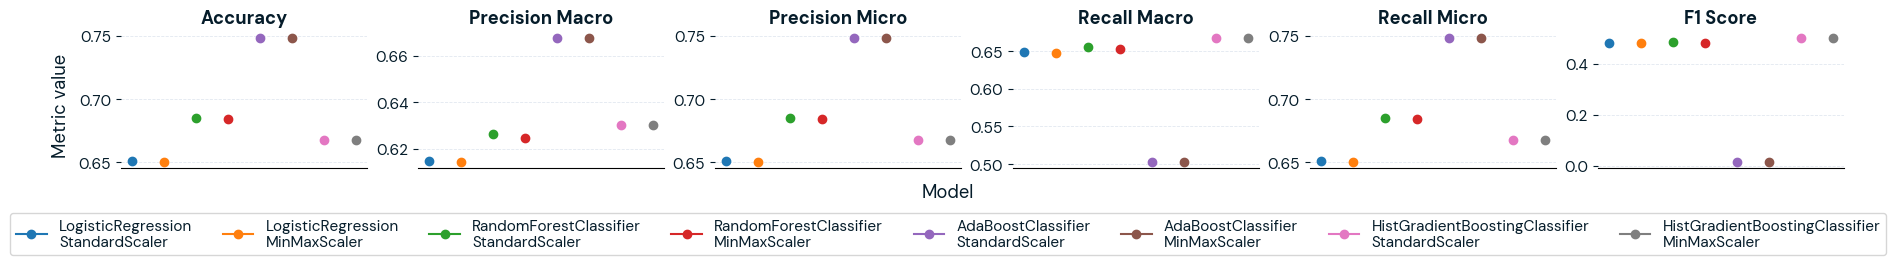

accuracy  precision_macro  \
LogisticRegression             StandardScaler  0.651028         0.614644   
                               MinMaxScaler    0.650650         0.614421   
RandomForestClassifier         StandardScaler  0.685458         0.626446   
                               MinMaxScaler    0.684576         0.624661   
AdaBoostClassifier             StandardScaler  0.748644         0.667724   
                               MinMaxScaler    0.748644         0.667724   
HistGradientBoostingClassifier StandardScaler  0.667550         0.630152   
                               MinMaxScaler    0.667550         0.630152   

                                               precision_micro  recall_macro  \
LogisticRegression             StandardScaler         0.651028      0.648248   
                               MinMaxScaler           0.650650      0.647995   
RandomForestClassifier         StandardScaler         0.685458      0.654834   
                               MinMaxScaler           0.684576      0.652252   
AdaBoostClassifier             StandardScaler         0.748644      0.503243   
                               MinMaxScaler           0.748644      0.503243   
HistGradientBoostingClassifier StandardScaler         0.667550      0.667921   
                               MinMaxScaler           0.667550      0.667921   

                                               recall_micro  f1_score  
LogisticRegression             StandardScaler      0.651028  0.481350  
                               MinMaxScaler        0.650650  0.481079  
RandomForestClassifier         StandardScaler      0.685458  0.487253  
                               MinMaxScaler        0.684576  0.484011  
AdaBoostClassifier             StandardScaler      0.748644  0.016774  
                               MinMaxScaler        0.748644  0.016774  
HistGradientBoostingClassifier StandardScaler      0.667550  0.503391  
                               MinMaxScaler        0.667550  0.503391

In [ ]:
#derived from assignment_3_solutions
def plot_results(df: pd.DataFrame, cmap = plt.get_cmap('tab10'), ncol: Optional[int] = None):
    # Create model labels combining both index levels
    df = df.copy()
    df['model'] = [f'{model}\n{scaler}' for model, scaler in df.index]
    metrics = [col for col in df.columns if col != 'model']

    # Create subplots
    n_metrics = len(metrics)
    fig, axs = plt.subplots(1, n_metrics, figsize=(3 * n_metrics, 2), constrained_layout=True)
    axs = axs.flatten()

    colors = [cmap(i) for i in range(len(df))]


    for ax, metric in zip(axs, metrics, strict=True):
        # Plot horizontal lines with markers for each model
        for i, (_, row) in enumerate(df.iterrows()):
            ax.plot(i, row[metric], 'o-', color=colors[i], label=row['model'])

        ax.set_title(metric.replace('_', ' ').title())
        ax.set_xticks([])

    # Add a single legend for all subplots
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.), ncol=len(labels) if ncol is None else ncol)
    fig.supxlabel('Model')
    fig.supylabel('Metric value')

    plt.show()

df_results = pd.DataFrame(results).T
plot_results(df_results)
df_results

Winning model: HistGradientBoostingClassifier, although lower accuracy than RF, it has higher f1_score.

The F1 scores increased a lot for all models except AdaBoost:
1.   HistGradientBoosting: ~0.25 -> ~0.50
2.   Logistic Regression: ~0.18 -> ~0.48
3.   Random Forest: ~0.18 -> ~0.48
4.   AdaBoost: ~0.2 -> ~0.016


Logistic Regression: The accuracy dropped, but it's because the models is less overfitting and more balanced.

Random Forest: Only the F1 increased significantly, because the this model is already kind of regularized by using an ensemble of trees.

AdaBoost: This model has the highest accuracy, but the F1 score is extremly low, because it almost stopped predicitng the positive class.

HistGradientBoostingClassifier: With an F1 score of 0.50339, it performs better than the models mentioned above: the model recall increased with a 'good' precision.

As expected, overall accuracy dropped for all models.






Learning Curve Gap: 0.031
Validation Curve Best CV F1: 0.4917 at L2=100


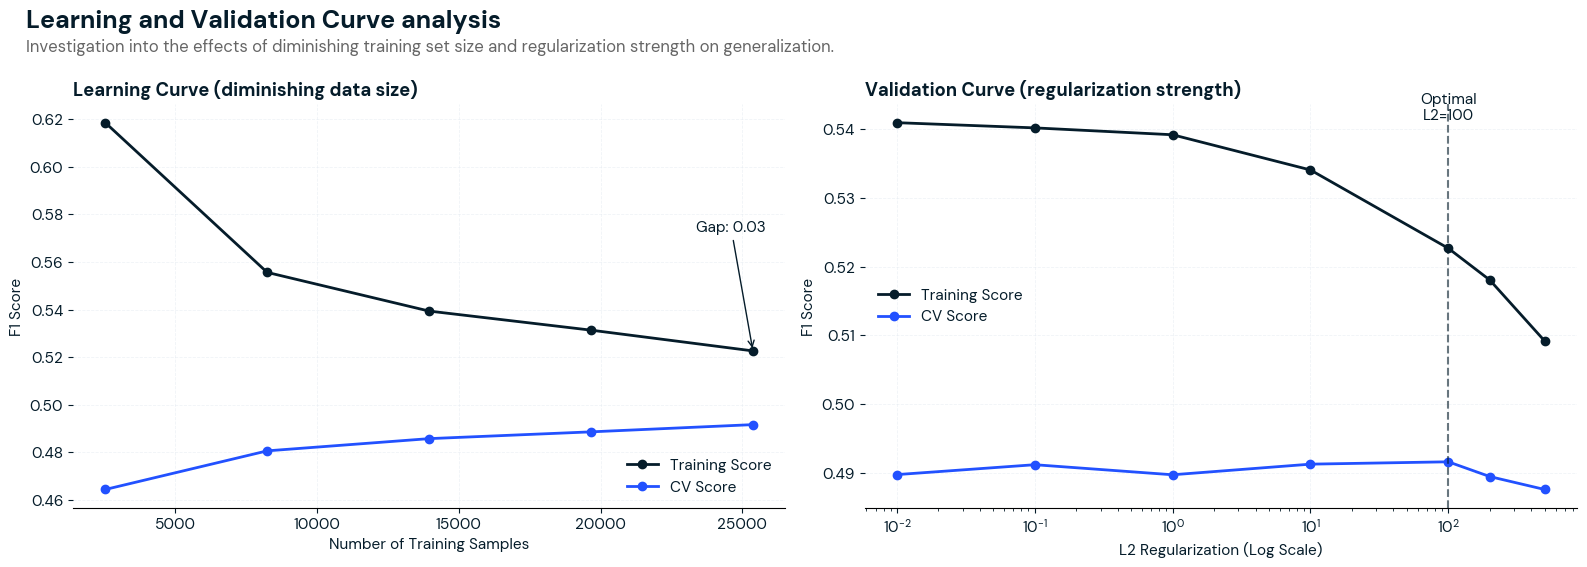

In [ ]:
#############################################################################################################
#LEARNING CURVE & VALIDATION CURVE ANALYSIS (1)
#############################################################################################################


best_model = Pipeline([
    ('scaler', StandardScaler()), # StandardScaler performed slightly better/equal
    ('estimator', HistGradientBoostingClassifier(
        learning_rate=0.05,
        l2_regularization=100.0,
        max_leaf_nodes=20,
        min_samples_leaf=20,
        random_state=42,
        class_weight='balanced',
        max_iter=100
    ))
])

#learning curve w/ diminishing data size
train_sizes, train_scores_lc, test_scores_lc = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

train_mean_lc = np.mean(train_scores_lc, axis=1)
test_mean_lc = np.mean(test_scores_lc, axis=1)

print(f"Learning Curve Gap: {round(train_mean_lc[-1] - test_mean_lc[-1], 4)}")

#validation curve w/ regularization effect
param_range = [0.01, 0.1, 1, 10, 100, 200, 500] #regularization strengths
train_scores_vc, test_scores_vc = validation_curve(
    best_model, X_train, y_train,
    param_name="estimator__l2_regularization",
    param_range=param_range,
    cv=5, scoring="f1", n_jobs=-1
)
train_mean_vc = np.mean(train_scores_vc, axis=1)
test_mean_vc = np.mean(test_scores_vc, axis=1)

print(f"Validation Curve Best CV F1: {max(test_mean_vc):.4f} at L2={param_range[np.argmax(test_mean_vc)]}")

#ploting both
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#learning curve
axes[0].plot(train_sizes, train_mean_lc, 'o-', color=PRIMARY, label="Training Score", linewidth=2)
axes[0].plot(train_sizes, test_mean_lc, 'o-', color=BLUE, label="CV Score", linewidth=2)

axes[0].set_title("Learning Curve (diminishing data size)", fontweight='bold', loc='left', color=PRIMARY)
axes[0].set_xlabel("Number of Training Samples")
axes[0].set_ylabel("F1 Score")
axes[0].legend(frameon=False, loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.5)

#gap
gap = train_mean_lc[-1] - test_mean_lc[-1]
axes[0].annotate(f"Gap: {gap:.2f}", xy=(train_sizes[-1], train_mean_lc[-1]),
                 xytext=(train_sizes[-1]-2000, train_mean_lc[-1] + 0.05),
                 arrowprops=dict(arrowstyle="->", color=ACCENT),
                 color=ACCENT, fontweight='normal')

#validation curve w/ semilogx bcs of log scale for regularization
axes[1].semilogx(param_range, train_mean_vc, 'o-', color=PRIMARY, label="Training Score", linewidth=2)
axes[1].semilogx(param_range, test_mean_vc, 'o-', color=BLUE, label="CV Score", linewidth=2)

axes[1].set_title("Validation Curve (regularization strength)", fontweight='bold', loc='left', color=PRIMARY)
axes[1].set_xlabel("L2 Regularization (Log Scale)")
axes[1].set_ylabel("F1 Score")
axes[1].legend(frameon=False, loc='best')
axes[1].grid(True, linestyle='--', alpha=0.5)

#optimal L2
best_idx = np.argmax(test_mean_vc)
optimal_l2 = param_range[best_idx]
axes[1].axvline(optimal_l2, color=ACCENT, linestyle='--', alpha=0.6)
axes[1].text(optimal_l2, train_mean_vc.max(), f"Optimal\nL2={optimal_l2}",
             color=ACCENT, ha='center', va='bottom', fontweight='normal')

#main title, subtitle
fig.text(0.02, 0.96, "Learning and Validation Curve analysis",
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Investigation into the effects of diminishing training set size and regularization strength on generalization.",
         fontsize=12, ha='left', color='#666666')

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()

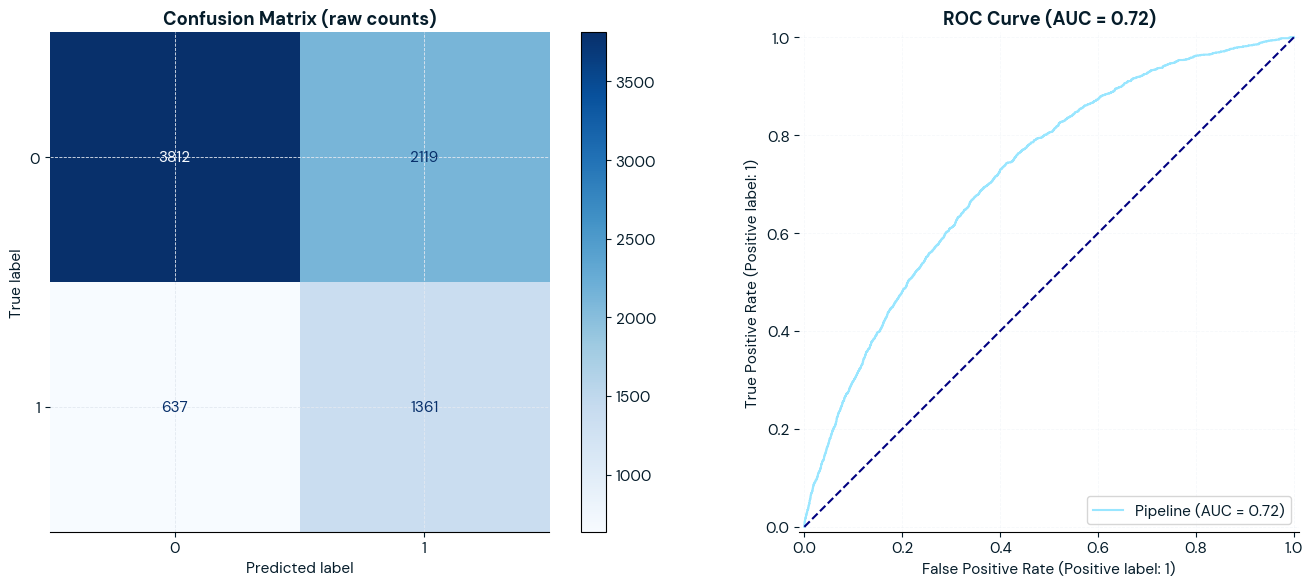


Classification Report
              precision    recall  f1-score   support

 Not Popular       0.86      0.64      0.73      5931
     Popular       0.39      0.68      0.50      1998

    accuracy                           0.65      7929
   macro avg       0.62      0.66      0.62      7929
weighted avg       0.74      0.65      0.67      7929



In [ ]:
#############################################################################################################
# FINAL EVALUATION OF WINNING MODEL
#############################################################################################################

#re init the best model with optimal hyperparameters
best_model = Pipeline([
    ('scaler', StandardScaler()), # StandardScaler performed slightly better/equal
    ('estimator', HistGradientBoostingClassifier(
        learning_rate=0.05,
        l2_regularization=100.0,
        max_leaf_nodes=20,
        min_samples_leaf=20,
        random_state=42,
        class_weight='balanced',
        max_iter=100
    ))
])

#train winning model
best_model.fit(X_train, y_train)


y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] #P(viral)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    ax=axes[0],
    cmap='Blues',
    normalize=None
)
axes[0].set_title("Confusion Matrix (raw counts)")

#ROC curve
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    ax=axes[1],
    color=TEAL
)


axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title(f"ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.2f})")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=['Not Popular', 'Popular']))


0 = not popular

1 = popular


The model has a recall of 0.68, which is pretty good given the class imbalance, but the precision for popular articles is still low (0.40). This is because there are still a lot of false positives. Hence, this model focuses on not missing potential popular articles, even though it categorizes some ordinary articles as a popular article.


The AUC score of 0.72 means that in 72% of randomly chosen not popular-popular pairs, the model assigns a higher score to the popular article

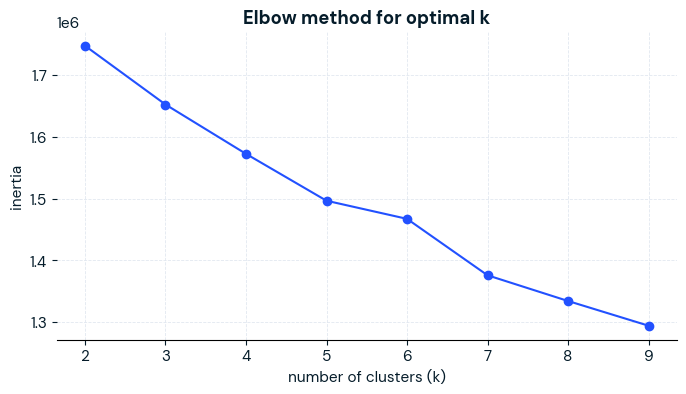

Popularity distribution per cluster:
Cluster_ID
0    0.262709
1    0.321888
2    0.231227
3    0.272530
4    1.000000
Name: is_popular, dtype: float64


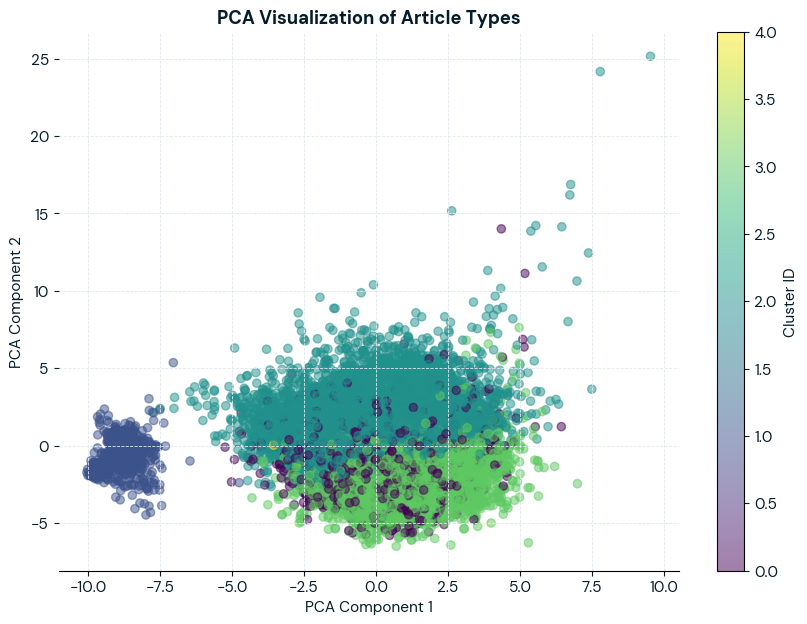

In [ ]:
###############################################################################################################
# K-MEANS CLUSTERING OF ARTICLE TYPES
###############################################################################################################

#prep data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

#elbow method to find/select optimal k
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'o-', color=BLUE)
plt.title('Elbow method for optimal k')
plt.xlabel('number of clusters (k)')
plt.ylabel('inertia')
plt.show()

#k-means clustering with chosen k=5
kmeans_features = KMeans(n_clusters=5, random_state=42, n_init=10)
feature_clusters = kmeans_features.fit_predict(X_scaled)

#analyze clusters
df_analysis = X_train.copy()
df_analysis['Cluster_ID'] = feature_clusters
df_analysis['is_popular'] = y_train

#print cluster sizes
print("Popularity distribution per cluster:")
print(df_analysis.groupby('Cluster_ID')['is_popular'].mean())

#pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
#scatter plot colored by cluster
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=feature_clusters, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Cluster ID')
plt.title('PCA Visualization of Article Types')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

Based on the Elbow method, we see diminishing returns after k=5, so we choose k=5 for the clustering.

Popularity distribution per cluster:\
Cluster_ID\
0    0.262709\
1    0.321888\
2    0.231227\
3    0.272530\
4    1.000000

We observe something really particular: cluster 4 shows a 100% popularity rate. We will investigate this below.

The PCA scatterplot shows that most articles types overlap heavily, but cluster 1 appears clearly seperated. We also observe that Cluster 4 is just a single yellow data point.

Cluster 4 Size: 1 articles

Cluster 4 top drivers compared to average article:
n_unique_tokens                  131860.914104
n_non_stop_words                 107244.447505
n_non_stop_unique_tokens          96407.473957
num_imgs                           1029.171525
data_channel_is_entertainment       460.021190
weekday_is_tuesday                  439.262030
is_popular                          296.921151
num_self_hrefs                      203.152542
n_tokens_content                    187.936890
kw_min_avg                          116.724429
dtype: float64


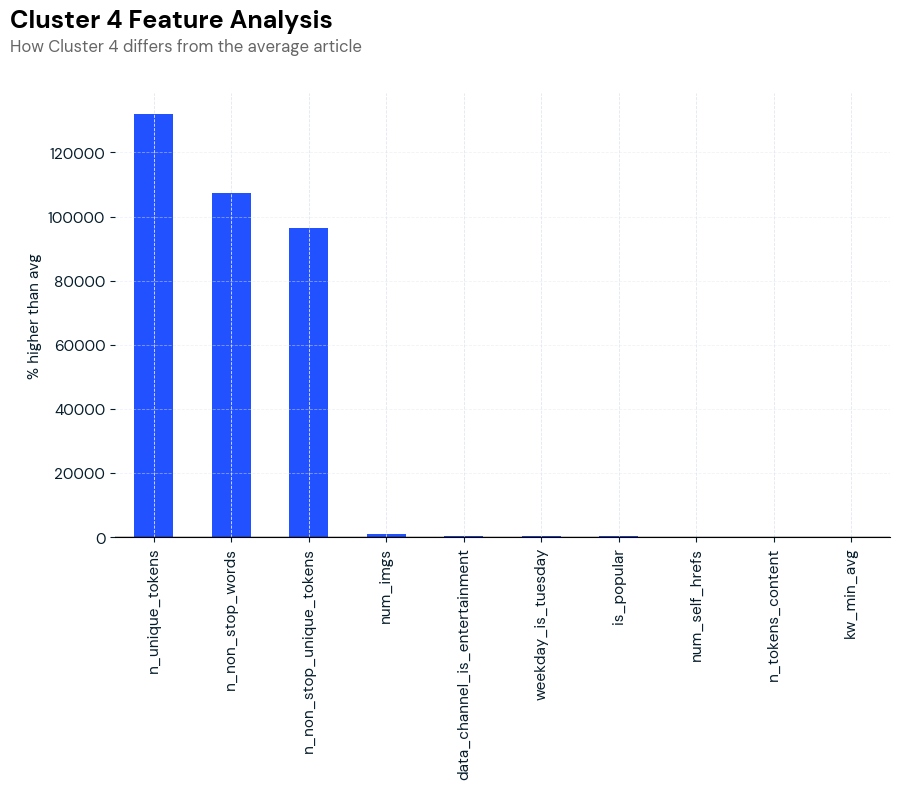

In [ ]:
#seperate cluster 4 from rest
cluster_3 = df_analysis[df_analysis['Cluster_ID'] == 4]
rest_of_data = df_analysis[df_analysis['Cluster_ID'] != 4]

print(f"Cluster 4 Size: {len(cluster_3)} articles")

# calculate means
means_c3 = cluster_3.mean()
means_rest = rest_of_data.mean()

diff_c3 = ((means_c3 - means_rest) / means_rest * 100).sort_values(ascending=False)

# top drivers
top_drivers = diff_c3.head(10)

print("\nCluster 4 top drivers compared to average article:")
print(top_drivers)

#visualize
fig, ax = plt.subplots(figsize=(10, 6))
top_drivers.plot(kind='bar', color=BLUE, ax=ax)
ax.set_ylabel('% higher than avg')
ax.axhline(0, color='black', linewidth=1)
ax.grid(axis='y', linestyle='--', alpha=0.5)
fig.text(0.02, 0.96, "Cluster 4 Feature Analysis",
         fontsize=18, fontweight='bold', ha='left', color='black')
fig.text(0.02, 0.92, "How Cluster 4 differs from the average article",
         fontsize=12, ha='left', color='#666666')
plt.subplots_adjust(top=0.85)
plt.show()

Cluster 4 is an Anomaly: it contains only 1 article with a enourmous amount of n_unique_tokens, n_non_stop_words, n_non_stop_unique_tokens compared to regular articles.
It is impossible to have 131,860% more n_unique tokens than an average article, so we conclude that this data point is corrupted. Therefore, we will ignore cluster 4 in our analysis.


Super Popular Threshold (99th percentile): 31657 shares


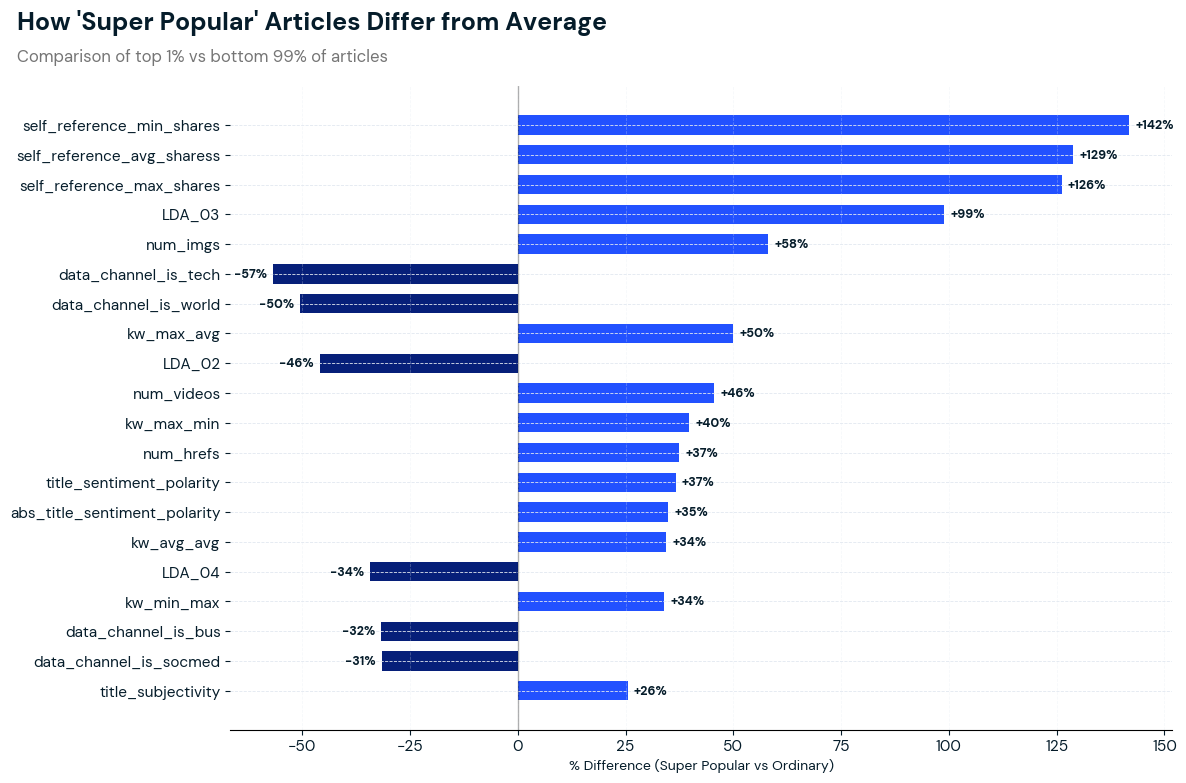

Popular Threshold: 2800 shares
Count: 9989 Popular vs 29655 Not Popular


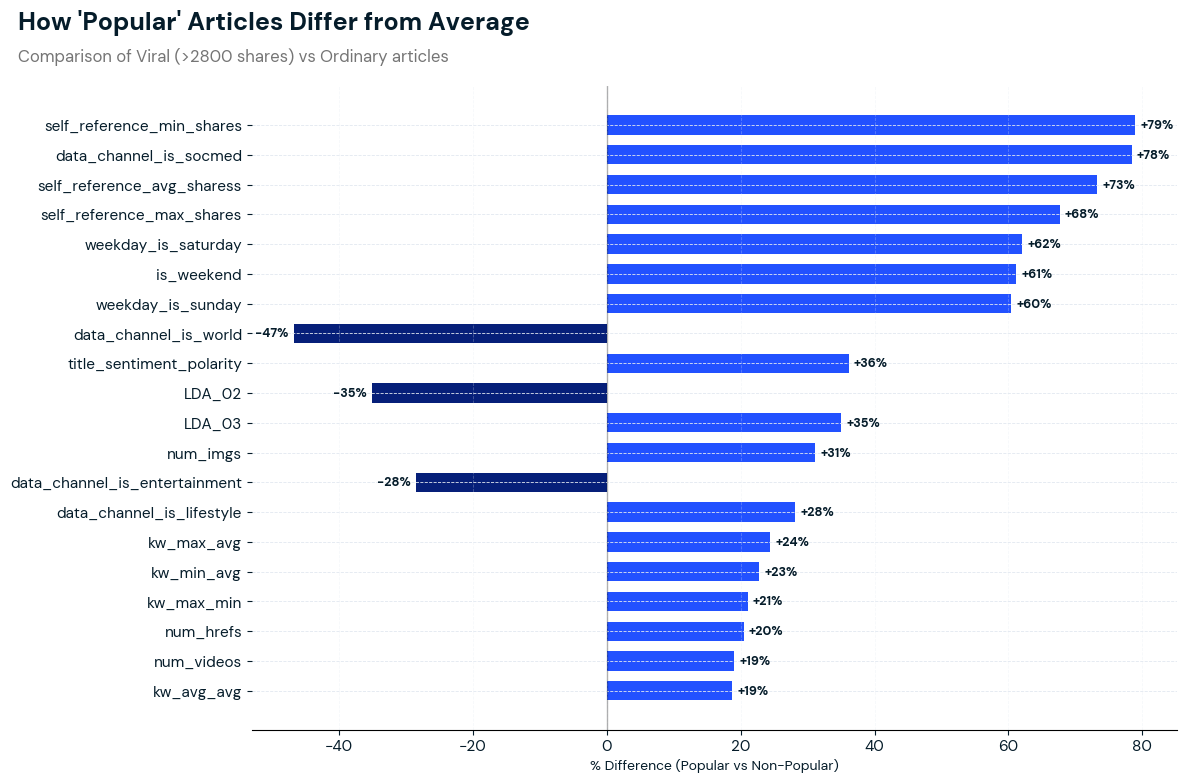

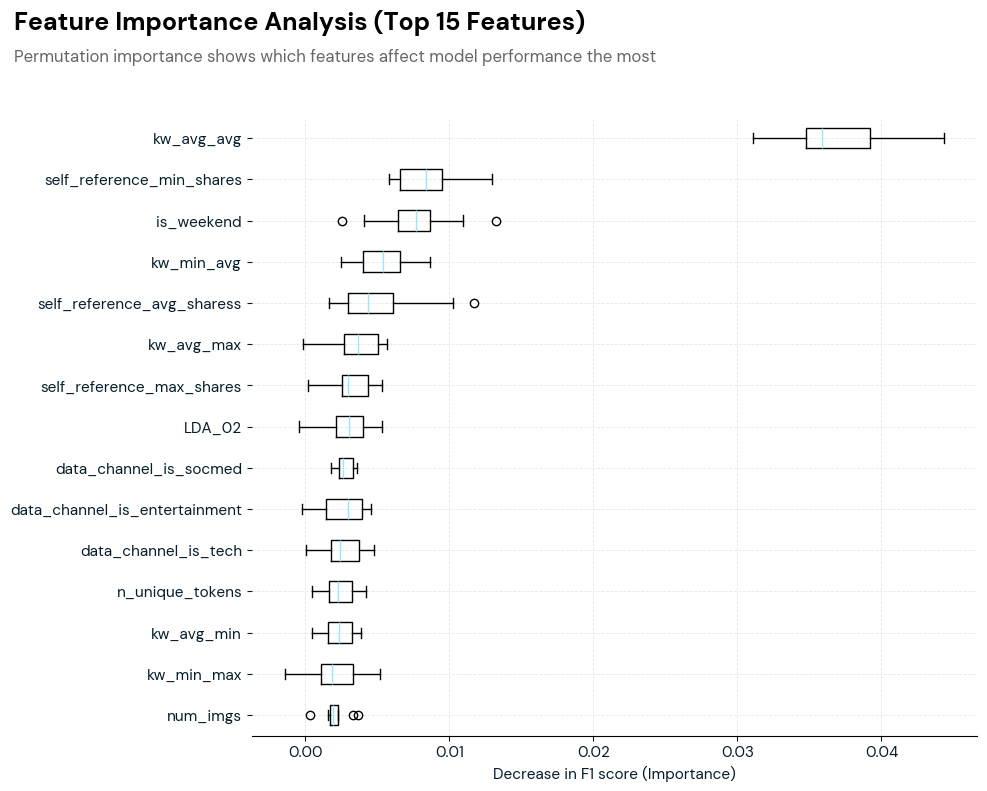


Top 5 Important virality features based on Permutation Importance:
1. kw_avg_avg
2. self_reference_min_shares
3. is_weekend
4. kw_min_avg
5. self_reference_avg_sharess


In [ ]:
############################################################################################################
# PART 1: "SUPER POPULAR (top 1%)" DESCRIPTIVE ANALYSIS
############################################################################################################

#super popular top 1%
threshold_super = df['shares'].quantile(0.99)
df_super = df[df['shares'] >= threshold_super]
df_ordinary = df[df['shares'] < threshold_super]

print(f"Super Popular Threshold (99th percentile): {threshold_super:.0f} shares")

#select cols
numeric_cols = df.select_dtypes(include=np.number).columns.drop(['shares', 'is_popular'], errors='ignore')

#% diff
diff_pct = (df_super[numeric_cols].mean() - df_ordinary[numeric_cols].mean()) / df_ordinary[numeric_cols].mean() * 100

#filter by top 20 absolute
top_idx = diff_pct.abs().nlargest(20).index
top_deviations = diff_pct.loc[top_idx]

#sort by absolute value for plotting
top_sorted = top_deviations.reindex(top_deviations.abs().sort_values(ascending=True).index)



#plotting
fig, ax = plt.subplots(figsize=(12, 8))
bar_colors = np.where(top_sorted > 0, BLUE, NAVY)
bars = ax.barh(top_sorted.index, top_sorted.values, color=bar_colors, height=0.65)
ax.set_xlabel("% Difference (Super Popular vs Ordinary)", fontsize=10, color=PRIMARY)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)
ax.grid(axis='x', linestyle='--', alpha=0.3)
max_val = top_sorted.abs().max()
offset = max_val * 0.01 #dynamic padding

for bar in bars:
    width = bar.get_width()
    label_text = f"{width:+.0f}%" #format

    if width < 0:
        x_pos = width - offset
        alignment = 'right'
    else:
        x_pos = width + offset
        alignment = 'left'

    ax.text(x_pos,
            bar.get_y() + bar.get_height()/2,
            label_text,
            va='center',
            ha=alignment,
            fontsize=9,
            color=PRIMARY,
            fontweight='bold')

fig.text(0.02, 0.95, "How 'Super Popular' Articles Differ from Average",
         fontsize=18, fontweight='bold', ha='left', color=PRIMARY)

fig.text(0.02, 0.91, f"Comparison of top 1% vs bottom 99% of articles",
         fontsize=12, ha='left', color=GRAY)

# Adjust layout to make room for the titles at the top
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

############################################################################################################
# PART 1+: "POPULAR (Viral > 2800)" DESCRIPTIVE ANALYSIS
############################################################################################################

#same logic but for viral threshold at 2800 shares
thres_pop = 2800
df_pop = df[df['shares'] >= thres_pop]
df_not_pop = df[df['shares'] < thres_pop]

print(f"Popular Threshold: {thres_pop} shares")
print(f"Count: {len(df_pop)} Popular vs {len(df_not_pop)} Not Popular")

numeric_cols = df.select_dtypes(include=np.number).columns.drop(['shares', 'is_popular'], errors='ignore')

diff_pct_pop = (df_pop[numeric_cols].mean() - df_not_pop[numeric_cols].mean()) / df_not_pop[numeric_cols].mean() * 100

top_idx_pop = diff_pct_pop.abs().nlargest(20).index
top_deviations_pop = diff_pct_pop.loc[top_idx_pop]
top_sorted_pop = top_deviations_pop.reindex(top_deviations_pop.abs().sort_values(ascending=True).index)

#plotting
fig, ax = plt.subplots(figsize=(12, 8))
bar_colors = np.where(top_sorted_pop > 0, BLUE, NAVY)
bars = ax.barh(top_sorted_pop.index, top_sorted_pop.values, color=bar_colors, height=0.65)
ax.set_xlabel("% Difference (Popular vs Non-Popular)", fontsize=10, color=PRIMARY)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)
ax.grid(axis='x', linestyle='--', alpha=0.3)
max_val = top_sorted_pop.abs().max()
offset = max_val * 0.01

for bar in bars:
    width = bar.get_width()
    label_text = f"{width:+.0f}%"

    if width < 0:
        x_pos = width - offset
        alignment = 'right'
    else:
        x_pos = width + offset
        alignment = 'left'

    ax.text(x_pos,
            bar.get_y() + bar.get_height()/2,
            label_text,
            va='center', ha=alignment,
            fontsize=9, color=PRIMARY, fontweight='bold')

fig.text(0.02, 0.95, "How 'Popular' Articles Differ from Average",
         fontsize=18, fontweight='bold', ha='left', color=PRIMARY)

fig.text(0.02, 0.91, f"Comparison of Viral (>2800 shares) vs Ordinary articles",
         fontsize=12, ha='left', color=GRAY)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

############################################################################################################
# PART 2: MODEL FEATURE IMPORTANCE (Permutation Importance bcs were using HistGradientBoosting instead of RandomForest)
############################################################################################################

#compute permutation importance
result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='f1' #f1 score to handle class imbalance
)

#organize results
sorted_idx = result.importances_mean.argsort()
top_n = 15

#plotting
fig, ax = plt.subplots(figsize=(10, 8))

ax.boxplot(
    result.importances[sorted_idx][-top_n:].T,
    vert=False,
    tick_labels=X_test.columns[sorted_idx][-top_n:]
)
ax.set_xlabel("Decrease in F1 score (Importance)")

fig.text(0.02, 0.96, "Feature Importance Analysis (Top 15 Features)",
         fontsize=18, fontweight='bold', ha='left', color='black')
fig.text(0.02, 0.92, "Permutation importance shows which features affect model performance the most",
         fontsize=12, ha='left', color='#666666')

plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.show()

#print the top 5 distinct features for your report
print("\nTop 5 Important virality features based on Permutation Importance:")
top_features = X_test.columns[sorted_idx][-5:][::-1]
for i, feat in enumerate(top_features, 1):
    print(f"{i}. {feat}")

We use Permutation Importance instead of Feature Importance since HistGradientBoostClassifier doesn't natively support Feature Importance. We observe that kw_avg_avg is the most important feature for virality.

We observe that articles connected to popular search terms (kw_avg_avg) is the most important featurre for virality. Linking other popular articles in the main article also has a major role predicting popularity (self_reference_avg_sharess) . We also observe that articles associated with very popular or trending keywords (kw_max_avg) have a increased chance of gaining many shares. Another important predictor is that the least popular linked article still tends to have more shares when the main article becomes popular (self_reference_min_shares). Finally we found that popular articles are often about topics that are already consistently popular.



To achieve 70% Precision:
New Threshold: 0.7727
Resulting Recall: 0.0190


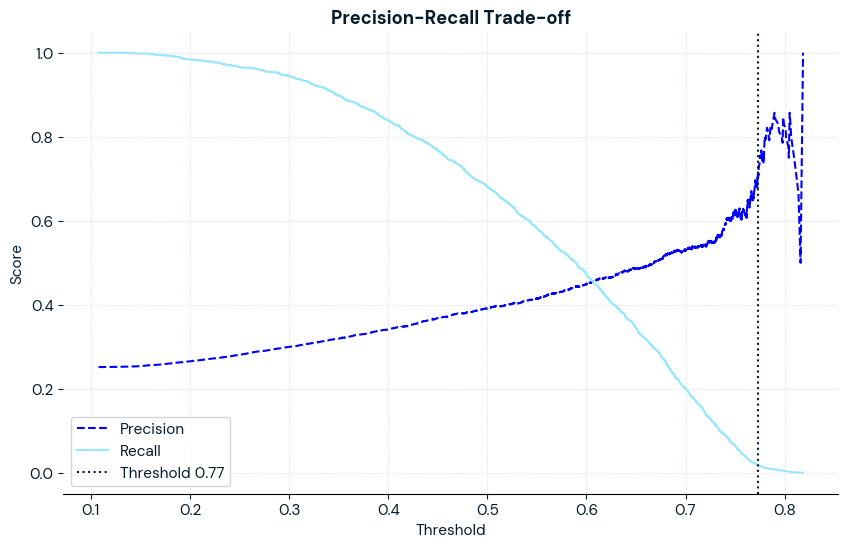

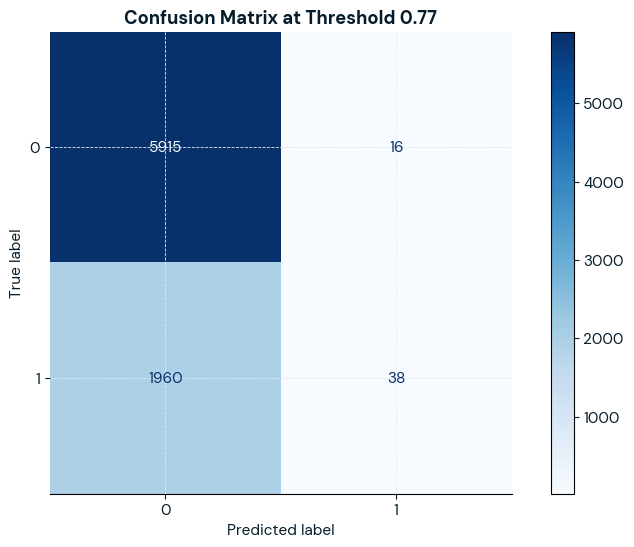

In [ ]:
############################################################################################################
# PART 3: THRESHOLD ADJUSTMENT TO IMPROVE PRECISION
############################################################################################################

#get predicted probabilities
y_scores = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)
target_precision = 0.70

#find the threshold for desired precision
idx = np.where(precisions >= target_precision)[0][0]
optimal_threshold = thresholds[idx]

print(f"To achieve {target_precision*100:.0f}% Precision:")
print(f"New Threshold: {optimal_threshold:.4f}")
print(f"Resulting Recall: {recalls[idx]:.4f}")


#plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], TEAL, label="Recall")
plt.axvline(optimal_threshold, color=ACCENT, linestyle=":", label=f"Threshold {optimal_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(loc="best")
plt.title("Precision-Recall Trade-off")
plt.show()

#confusion matrix at new threshold
y_pred_new = (y_scores >= optimal_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_new, cmap='Blues')
plt.title(f"Confusion Matrix at Threshold {optimal_threshold:.2f}")
plt.show()

We tried to improve precision, but in this graph it can be seen that to achieve 70% precision we need a threshold of 0.7940 which results in a recall of only 0.0140. In the confusion matrix we can see that there are 1970 false negatives. Therefore we cannot increase the precision, since the model would be missing out on too many viral articles.